# Start


In [1]:
import torch
from dataclasses import dataclass
from typing import Optional
# from ome

from icl import generate_dual_task_batch, get_distributions, MinimalTransformer, initialize_model, get_triggers

In [37]:
@dataclass
class cfg:
    vocab_size: int =  5 # Vocabulary size
    seq_len: int = 10 # Sequence length
    d_model: int = 512 # Model dimension
    rank: int = 16   # rank or matrices
    dropout: float = 0.0 # Dropout rate
    lin_attn: bool = True # Whether to use linear attention or not
    beta: float = 0.5 # Scaling factor for the output logits (inverse of the temperature)
    b_type: str = 'spiked' # P_b distribution type: dirichlet or spiked
    alpha_d: float = 0.1 # Dirichlet concentration parameter for bigram distribution (only used if b_type is dirichlet or u_type is dirichlet)
    alpha_z: Optional[float] = 1.0 # Exponent for the Zipf distribution used to generate the unigram distribution P_u if b_type is 'spiked' and u_type is 'zipf'
    u_type: Optional[str] = 'uniform' # P_u distribution type: dirichlet or zipf (only used if b_type is spiked)
    beta: Optional[float] = 0. # Beta parameter for spiked bigram distribution (only used if b_type is spiked)
    fix_trig: bool = True # Whether to fix the trigger tokens or not
    trig_type: Optional[str] = 'freq' # Type of fixed trigger tokens if fix_trig is True (options are 'freq', 'rare' and 'rand')
    batch_size: int = 1024 # Batch size for training
    test_size: int = 200 # Number of samples in the test set
    K : int = 4 # Number of trigger tokens  


# Define device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# Define distributions
distributions = get_distributions(cfg, cfg.vocab_size, device=device)

# Initialize model
model = MinimalTransformer(cfg).to(device)
model = initialize_model(model)

# Define triggers
trigger_set = get_triggers(cfg, distributions['P_t'])#.to(device)

Generating spiked bigram distribution with and beta =  0.0
Generating unigram distribution from a uniform distribution
Using fixed freq trigger set
Length of trigger set: 4, Trigger set: [0, 1, 2, 3]


In [50]:
batch = generate_dual_task_batch(3,cfg.seq_len,cfg.K,distributions,trigger_set,device=device)

In [51]:
print("Batch generated successfully.")
for key, value in batch.items():
    print(f"{key}: {value.shape if isinstance(value, torch.Tensor) else value}")

Batch generated successfully.
sequence: torch.Size([3, 11])
trigger_set: torch.Size([3, 4])
output_set: torch.Size([3, 4])
counts: torch.Size([3, 10])
is_trigg: torch.Size([3, 10])
mask: torch.Size([3, 10, 10])


In [52]:
logits = model(batch['sequence'][:, :-1].to(device), batch['mask'].to(device)) # shape (batch_size, seq_len, vocab_size)
print("Logits generated successfully.")
print(f"logits: {logits.shape}")

Logits generated successfully.
logits: torch.Size([3, 10, 5])


In [53]:
# generate a mask to apply to the logits (shape(B,L,V)) such that each element (b,l,v) is true
# it the input token at position l in batch b is a trigger and the counts for that trigger are larger than 1
# and the corresponding output token is v. This mask will be used to compute the on-target and off-target logits for each trigger token in the batch.

on_target_mask = batch["is_trigg"].bool().unsqueeze(-1) & (batch["counts"] > 1).unsqueeze(-1) 
on_target_mask = on_target_mask & (torch.arange(logits.size(-1), device=logits.device).view(1, 1, -1) == batch["sequence"][:, 1:].unsqueeze(-1))

print(batch["sequence"],f'\n')
print(batch["is_trigg"],f'\n')
print(batch["counts"],f'\n')
print(on_target_mask)

print(logits[on_target_mask])


tensor([[2, 4, 3, 4, 1, 3, 4, 0, 2, 4, 4],
        [4, 4, 2, 0, 1, 4, 3, 1, 4, 3, 1],
        [2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2]], device='cuda:0') 

tensor([[1, 0, 1, 0, 1, 1, 0, 1, 1, 0],
        [0, 0, 1, 1, 1, 0, 1, 1, 0, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0') 

tensor([[1, 1, 1, 2, 1, 2, 3, 1, 2, 4],
        [1, 2, 1, 1, 1, 3, 1, 2, 4, 2],
        [1, 1, 2, 2, 3, 3, 4, 4, 5, 5]], device='cuda:0') 

tensor([[[False, False, False, False, False],
         [False, False, False, False, False],
         [False, False, False, False, False],
         [False, False, False, False, False],
         [False, False, False, False, False],
         [False, False, False, False,  True],
         [False, False, False, False, False],
         [False, False, False, False, False],
         [False, False, False, False,  True],
         [False, False, False, False, False]],

        [[False, False, False, False, False],
         [False, False, False, False, False],
         [False, 

In [49]:
batch["sequence"][:, 1:].unsqueeze(-1)

tensor([[[3],
         [2],
         [1],
         [4],
         [1],
         [4],
         [2],
         [1],
         [4],
         [4]]], device='cuda:0')

# Plots

In [44]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from icl.evaluation.utils import on_off_logit_masks
from tracklab import ExperimentReader
from configurations.plot_config import create_fig, set_font_sizes, apply_general_styles
apply_general_styles()
set_font_sizes(conf='tight')

In [45]:
# Define a function to plot empty squares for mask=1 on an existing axis
def plot_mask_squares(ax, mask,lw=0.5,color='red',alpha=1.0):
    """
    Plots empty squares on the given axis where mask=1.

    Parameters:
    ax : matplotlib.axes.Axes
        The axis on which to plot the squares.
    mask : numpy.ndarray
        A 2D array where squares are drawn for elements equal to 1.
    """
    for i in range(mask.shape[0]):
        for j in range(mask.shape[1]):
            if mask[i, j] == 1:
                rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor=color, linewidth=lw, alpha=alpha)
                ax.add_patch(rect)
    ax.set_xlim(-0.5, mask.shape[1] - 0.5)
    ax.set_ylim(-0.5, mask.shape[0] - 0.5)
    ax.invert_yaxis()
    ax.set_aspect('equal')


In [47]:
experiment_name = "logits"
reader = ExperimentReader(experiment_name, base_dir='../data')
run_id = reader.list_runs()[-1]
print(f"Loading run {run_id} from experiment {experiment_name}")

df = reader.load_metrics(run_id)
data = df.pivot(index='step', columns='metric', values='value').reset_index()

list_artifacts = reader.list_artifacts(run_id)
matrix_steps = list_artifacts['step'][1:].astype(int).to_list()
ninit = len(matrix_steps) // 2 
steps_to_plot = matrix_steps[ninit-1:ninit+3]
logits_to_plot = [reader.load_artifact(run_id,f'logits_step_{step}.npy') for step in steps_to_plot]
batch = reader.load_artifact(run_id,'sub_batch.pkl')
print(f"Matrix steps: {matrix_steps}")
# print(list_artifacts)
# print(logits_to_plot[0].shape)
# for key, value in batch.items():

#     print(f"{key}")
#     print(f"{value.shape if isinstance(value, torch.Tensor) else value}")

i_batch_list = np.argsort(np.max(logits_to_plot[-1].reshape(logits_to_plot[-1].shape[0], -1), axis=1))[::-1]
# print(f"Batch index with highest logits: {i_batch}")
V = logits_to_plot[0].shape[-1]
K = batch['trigger_set'][0].shape[0]
print(f"Vocab size: {V}, K: {K}")
rho = K/V
print(f"rho: {rho}")
rank = reader.load_config(run_id)['model_args']['rank']
# rank



Loading run run_019 from experiment logits


FileNotFoundError: [Errno 2] No such file or directory: '../data/logits/run_019/artifacts/logits_step_192.npy'

NameError: name 'data' is not defined

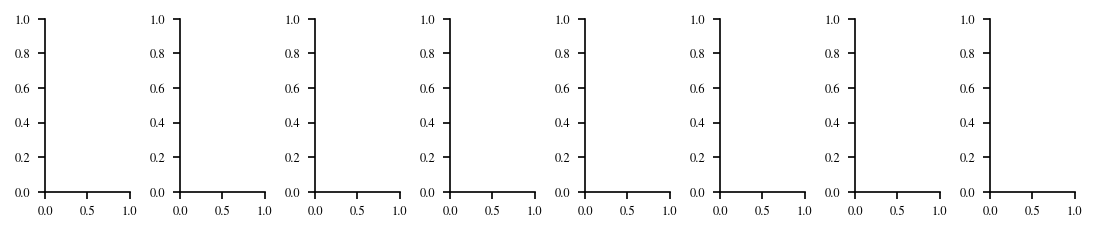

In [5]:
# Plot for order parameters:

params = ['m','Q','Gamma','var_on','var_off','h_star','off_target_std','on_target_std']
fig , axes = create_fig(nrows=1,ncols=len(params),size='double',h=0.2)
for i, param in enumerate(params):
    x = data[param]
    if 'var' in param:
        x = np.sqrt(data[param])
    
    axes[i].plot(data['step'],x,marker='.',markersize=4)
    axes[i].set_title(param)
    # axes[i].set_xlim(0,50)



plt.show()
plt.plot(data['step'],data['off_target_std'])
plt.plot(data['step'],data['on_target_std'])
plt.plot(data['step'],np.sqrt(data['var_off'] + data['var_on']))
plt.plot()

config = {
    'loss' : {'title': 'Loss'},
    'top1_accuracy' : {'title': 'Top-1 Acc.'},
    'on_target_mean' : {'title': r'On-Target $h^*$'},
    'off_target_mean' : {'title': r'Off-Target $h$'},
}
titles = ["Loss", "Top-1 Acc.", "On-Target Logits", "Off-Target Logits"]

# First plot for metrics
fig , axes = create_fig(nrows=2,ncols=2)

axes = axes.flatten()

for i , k  in enumerate(config.keys()):
    axes[i].plot(data['step'],data[k])
    axes[i].set_title(config[k]['title'])
    if i == 0 : 
        axes[i].axhline(np.log(V), color='r', linestyle='--', alpha=0.5, label='Random Guess')
        axes[i].axhline((1-rho)*np.log(V), color='b', linestyle='--', alpha=0.5, label='Random Guess')
        axes[i].plot(data['step'],data['L_eff'],linestyle='-',color='orange',label=r'$L_{eff}$')
    
    if i == 2:
        
        axes[i].plot(data['step'],data['h_star'],linestyle='--',color='green',label=r'$h^*$')
        # axes[i].plot(data['step'],data['on_target_emp'],linestyle='--',color='k',label=r'$h^*$')

    if i > 1:
        k_std = k.replace('mean','std')
        axes[i].set_xlabel("Step")
        axes[i].fill_between(data['step'],data[k]-data[k_std],data[k]+data[k_std],alpha=0.2)
    for step in steps_to_plot:
        axes[i].axvline(x=step, color='r', linestyle='--', alpha=0.5)

# Second Plot for Logits
i_batch = i_batch_list[0]
fig , axes = create_fig(ncols=len(logits_to_plot),nrows=2,size='double',h=0.5,sharex=False)

for i, logits in enumerate(logits_to_plot):
    log = logits[i_batch][2:]
    on_mask, off_mask, all_mask = on_off_logit_masks(logits.shape,batch)
    on_logits = logits[on_mask]
    off_logits = logits[off_mask]
    all_logits = logits[all_mask]

    im = axes[0,i].imshow(log,cmap='Greens',vmin=-10,vmax=10)
    plot_mask_squares(axes[0,i],on_mask[i_batch][2:],lw=0.5,color='red',alpha=1.0)
    # cbar = fig.colorbar(im, ax=axes[0,i],fraction=0.02, pad=0.04)
    # Plot the logits
    axes[0,i].set_title(f"Step {steps_to_plot[i]}")

    # Plot the distributions
    
    
    for x,c in zip([on_logits,off_logits],['red','blue']):
        axes[1,i].hist(x,range=(-10,20),bins=50,alpha=0.5,label='All',color=c,density=True,histtype='barstacked',rwidth=1,edgecolor='black')
    # axes[1,i].hist(off_logits,bins=20,alpha=0.5,label='All',color='blue',density=True,histtype='barstacked',rwidth=1,edgecolor='black')
    # axes[1,i].set_yscale('log')

In [43]:
for i in range(10,1,-1):
    print(i)
    if i == 5:
        break
print('a')


10
9
8
7
6
5
a


[1 2 3 2 2]


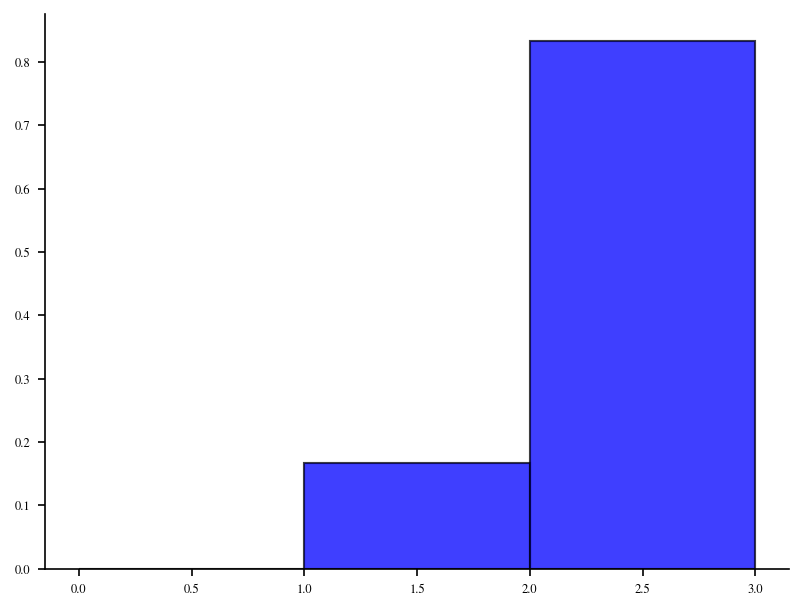

In [ ]:
x = np.array([1,2,3,2,2,2])

bins, edges = np.histogram(x, bins=3, range=(0,3), density=True)

plt.hist(x, bins=3, range=(0,3), density=True, alpha=0.5, color='blue', histtype='barstacked', rwidth=1, edgecolor='black'  )
plt.bar(edges[:-1], bins, width=np.diff(edges), edgecolor='black', align='edge', alpha=0.5, color='blue')

print(x[:-1])

torch.histogram(x,b)

In [ ]:
plt.bar

In [58]:
1500*150*0.1 * (4/32)**2 / (4 * 16 *16)

0.34332275390625

In [ ]:
dic1 = {'a':1, 'b':2}
dic2 = {'c':3, 'd':4}
dic1.update(dic2)
print(dic1)

TypeError: unsupported operand type(s) for +: 'dict' and 'dict'

# Expectation estimation

In [66]:
# import torch
import numpy as np
import matplotlib.pyplot as plt

from icl.evaluation.utils import on_off_logit_masks
from tracklab import ExperimentReader
from configurations.plot_config import create_fig, set_font_sizes, apply_general_styles
apply_general_styles()
set_font_sizes(conf='tight')

In [68]:
# import numpy as np
from scipy.integrate import dblquad
# import numpy as np
from numpy.polynomial.hermite import hermgauss  

def softplus(x):
    return np.log1p(np.exp(x))
def sigmoid(x):
    return 1 / (1 + np.exp(-x))



def function(z1, z2, h_star, sigma_star, sigma, V, K):
    # c1 = (V - 1) * np.exp(-h_star + 0.5 * sigma**2)
    # c2 = np.sqrt((V - 1) * (np.exp(sigma**2) - 1) * np.exp(sigma**2)) * np.exp(-h_star)

    # aux = 1 + c1 * np.exp(-sigma_star * z1) + c2 * z2 * np.exp(-sigma_star * z1)
    aux = 1 + (V - 1) * np.exp(-h_star) * np.exp(sigma *z1 - sigma_star*z2)
    aux = np.maximum(aux, 1e-10)

    return np.log(aux)


def gaussian_pdf(z):
    return np.exp(-0.5 * z**2) / np.sqrt(2 * np.pi)


def expectation_gh_time(h_star, sigma_star, sigma, V, K, n=40):
    """
    Computes E[function(Z1,Z2,...)] for each time point.

    Parameters
    ----------
    h_star, sigma_star, sigma : arrays of shape (T,)
    V, K : scalars
    n : int
        Number of Gauss-Hermite nodes.

    Returns
    -------
    E : ndarray of shape (T,)
    """
    h_star = np.asarray(h_star)
    sigma_star = np.asarray(sigma_star)
    sigma = np.asarray(sigma)
    x, w = hermgauss(n)
    z = np.sqrt(2) * x

    Z1, Z2 = np.meshgrid(z, z, indexing="ij")
    W = np.outer(w, w)

    # Add a time axis to the quadrature nodes
    Z1 = Z1[:, :, None]
    Z2 = Z2[:, :, None]

    F = function(
        Z1,
        Z2,
        h_star[None, None, :],
        sigma_star[None, None, :],
        sigma[None, None, :],
        V,
        K,
    )

    return np.sum(W[:, :, None] * F, axis=(0, 1)) / np.pi

def eff_loss(h_star,sigma_star,sigma,V,K,type=None):
    rho = K/V
    if type == 1:
        L_trigg = np.log(1+(V-1)*np.exp(-h_star))
    if type == 2:
        L_trigg = np.log(1+(V-1)*np.exp(-h_star + 0.5*sigma**2)) 
    if type == 3:
        # L_trigg = expectation_gh_time(h_star,sigma_star,sigma,V,K,n=70)
        sigma_s2 = np.log(1+(np.exp(sigma**2)-1)/(V-1))
        mu_s = np.log(V-1) + 0.5*(sigma**2 - sigma_s2)
        mu_y = mu_s - h_star
        tau2 = sigma_s2 + sigma_star**2
        L_trigg = softplus(mu_y) + 0.5*tau2*sigmoid(mu_y)*(1-sigmoid(mu_y))
    if type == 4:
        #  Full markov approximation
        L_trigg = np.zeros_like(h_star)
        for i in range(len(h_star)):
            m_star = h_star[i]
            sigma_star_i = sigma_star[i]
            sigma_i = sigma[i]
            on_logits = np.random.normal(m_star,sigma_star_i,size=(100000,))
            off_logits = np.random.normal(0,sigma_i,size=(100000,V-1))
            S = np.sum(np.exp(off_logits),axis=-1)
            loss = np.log(1 + S*np.exp(-on_logits))
            L_trigg[i] = np.mean(loss)
        

    return rho*L_trigg + (1-rho)*np.log(V)

In [82]:
experiment_name = "logits"
reader = ExperimentReader(experiment_name, base_dir='../data')
run_id = reader.list_runs()[-1]
print(f"Loading run {run_id} from experiment {experiment_name}")

df = reader.load_metrics(run_id)
data = df.pivot(index='step', columns='metric', values='value').reset_index()

cfg = reader.load_config(run_id)
V = cfg['model_args']['vocab_size']
K = cfg['data_args']['K']
rho = K/V

print(f"Vocab size: {V}, K: {K}, rho: {rho:.4f}")

Loading run run_043 from experiment logits
Vocab size: 105, K: 8, rho: 0.0762


Sample mean: 4.34527749197483


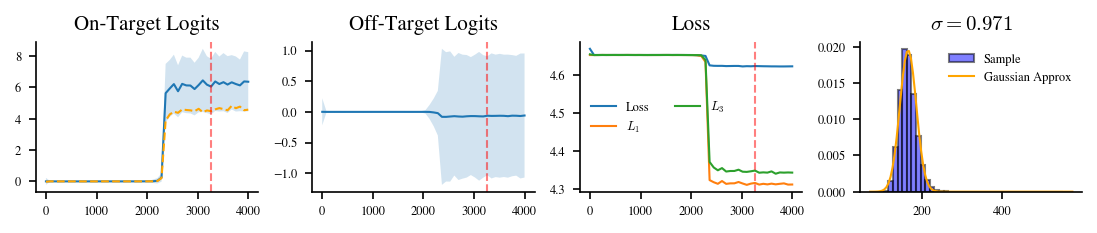

In [100]:
fig , axes = create_fig(nrows=1,ncols=4,size='double',h=0.2,sharex=False)

time_frac = 0.8
t_idx = int(time_frac*len(data['step']))

# On target logits
ax = axes[0]
ax.plot(data['step'],data['on_target_mean'])
ax.fill_between(data['step'],data['on_target_mean']-data['on_target_std'],data['on_target_mean']+data['on_target_std'],alpha=0.2)
ax.plot(data['step'],data['on_target_mean'] - 0.5*data['on_target_std']**2,ls='--',color='orange')
ax.axvline(x=data['step'][t_idx], color='r', linestyle='--', alpha=0.5)
ax.set_title("On-Target Logits")

# Off target logits
ax = axes[1]
ax.plot(data['step'],data['off_target_mean'])
ax.fill_between(data['step'],data['off_target_mean']-data['off_target_std'],data['off_target_mean']+data['off_target_std'],alpha=0.2)
ax.axvline(x=data['step'][t_idx], color='r', linestyle='--', alpha=0.5)
ax.set_title("Off-Target Logits")

# Loss
ax = axes[2]
ax.plot(data['step'],data['loss'],label='Loss')
for type in [1,3]:
    L_eff = eff_loss(data['on_target_mean'],data['on_target_std'],data['off_target_std'],V,K,type=type)
    ax.plot(data['step'],L_eff,label=f'$L_{type}$')
ax.axvline(x=data['step'][t_idx], color='r', linestyle='--', alpha=0.5)
ax.set_title("Loss")
ax.legend(frameon=False,fontsize=6,ncols=2)

# Distribution of sum of logits at a specific time point

m_star = data['on_target_mean'][t_idx]
sigma_star = data['on_target_std'][t_idx]
sigma = data['off_target_std'][t_idx]
ax = axes[3]
ax.set_title(rf"$\sigma = {sigma:.3}$")

# sample
n_samples = 1000000
z = np.random.normal(0,sigma,size=(n_samples,V-1))
S = np.sum(np.exp(z),axis=-1)
z_prime = np.random.normal(m_star,sigma_star,size=(n_samples,))
loss = np.log(1 + S*np.exp(-z_prime)).mean()
loss = rho*loss + (1-rho)*np.log(V)
print(f"Sample mean: {loss}")
ax.hist(S,bins=40,density=True,alpha=0.5,label='Sample',color='blue',histtype='barstacked',rwidth=1,edgecolor='black');
# ax.set_yscale('log')
#gauss approx 
# V = 32
vmin , vmax = ax.get_xlim()
m = (V-1)*np.exp(sigma**2/2)
s2 = (V-1)*(np.exp(sigma**2)-1)*np.exp(sigma**2)
x = np.linspace(vmin,vmax,100)
pdf = 1/np.sqrt(2*np.pi*s2)*np.exp(-(x-m)**2/(2*s2))
ax.plot(x,pdf,label='Gaussian Approx',color='orange')
ax.legend(frameon=False,fontsize=6)
# ax.set_yscale('log')

In [101]:
artifacts_list = reader.list_artifacts(run_id)
unique_steps = artifacts_list['step'][1:].astype(int).unique().tolist()
step_idx = int(time_frac * len(unique_steps))
print(f"Evaluateion time: {unique_steps[step_idx]}")
print(f"Unique steps: {unique_steps}")

# Extract the logits at the evaluation time step
name_hist = f'logits_histograms_step_{unique_steps[step_idx]}.pkl'
name_logits = f'logits_ind_step_{unique_steps[step_idx]}.npy'

hist = reader.load_artifact(run_id,name_hist)
edges = hist['edges']
dx = edges[1] - edges[0]
logits_ind = reader.load_artifact(run_id,name_logits)

print(f"Logits shape: {logits_ind.shape}")
print(hist.keys())


Evaluateion time: 3309
Unique steps: [0, 137, 275, 413, 551, 689, 827, 965, 1103, 1241, 1378, 1516, 1654, 1792, 1930, 2068, 2206, 2344, 2482, 2620, 2757, 2895, 3033, 3171, 3309, 3447, 3585, 3723, 3861, 3999]
Logits shape: (135, 105)
dict_keys(['on', 'off', 'all', 'edges'])


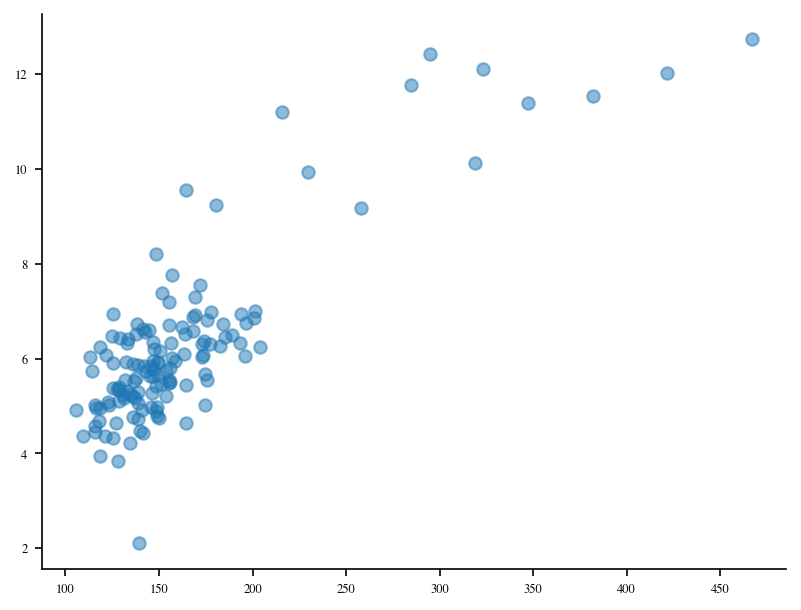

In [102]:
S = np.sum(np.exp(logits_ind[:,:-1]),axis=-1) # shape (num_indices,)
h_star = logits_ind[:,-1] # shape (num_indices,)

plt.scatter(S,h_star,alpha=0.5)

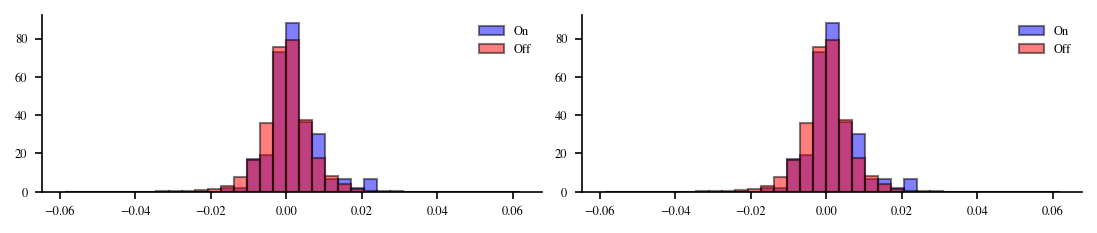

In [98]:
fig , axes = create_fig(nrows=1,ncols=2,size='double',h=0.2,sharex=False)

ax = axes[0]
ax.bar(edges[:-1], hist['on'], width=dx, align='edge', color='blue', alpha=0.5, edgecolor='black',label='On')
ax.bar(edges[:-1], hist['off'], width=dx, align='edge', color='red', alpha=0.5, edgecolor='black',label='Off')
ax.legend(frameon=False,fontsize=6)


ax = axes[1]
ax.hist(logits_ind[:, -1], bins=edges, alpha=0.5, color='blue', histtype='barstacked', rwidth=1, edgecolor='black', label='On',density=True)
ax.hist(logits_ind[:, :-1].flatten(), bins=edges, alpha=0.5, color='red', histtype='barstacked', rwidth=1, edgecolor='black', label='Off',density=True)
ax.legend(frameon=False,fontsize=6)

# Test distribution hipotesis

In [35]:
from icl.data.trigg_data import generate_icl_task_batch
import torch

def get_indices(test_batch,device):
    is_trigg = test_batch['is_trigg'].to(device) # shape (batch_size, seq_len)
    counts = test_batch['counts'].to(device) # shape (batch_size, seq_len)
    # Get indices where is_trigg == 1 and counts > 1 as idx that i can later use as sequence[idx] for example 
    # where sequence.shape = (batch_size, seq_len) and idx.shape = (num_indices, 2) where each row is (batch_index, seq_index)
    indices = torch.nonzero(is_trigg & (counts > 1), as_tuple=False) # shape (num_indices, 2)
    return indices

In [65]:
def get_indices(test_batch,device):
    is_trigg = test_batch['is_trigg'].to(device) # shape (batch_size, seq_len)
    counts = test_batch['counts'].to(device) # shape (batch_size, seq_len)
    # Get indices where is_trigg == 1 and counts > 1 as idx that i can later use as sequence[idx] for example 
    # where sequence.shape = (batch_size, seq_len) and idx.shape = (num_indices, 2) where each row is (batch_index, seq_index)
    indices = torch.nonzero(is_trigg & (counts > 1), as_tuple=False) # shape (num_indices, 2)
    return indices

B = 100
V = 50
L = 32
K = 10

batch = generate_icl_task_batch(B, V, L, K)
                                        #   device=device)
sequence = batch['sequence'].to('cpu') # shape (B,L+1)
output = sequence[:, 1:].to('cpu') # shape (B,L)
logit = torch.randn(B,L,V)


idx = get_indices(batch,device='cpu') # shape (num_indices, 2)
num_indices = idx.shape[0]
# evaluate is_trigg on the indices to get an array of shape (num_indices,) with the values of is_trigg at the indices
evaluated_logits = logit[idx[:,0], idx[:,1],:] # shape (num_indices, V)
evaluated_output = output[idx[:,0], idx[:,1]] # shape (num_indices,)




# Separate the evaluated_logits into 2 groups: the first 'on_target' (num_indices,) where for each index in idx we keep only the logit corresponding to the output token at that index, 
# and the second 'off_target' (num_indices, V-1) where for each index in idx we keep all the logits except for the logit corresponding to the output token at that index.


all_idx = torch.arange(V, device=evaluated_logits.device).expand(num_indices, V)
non_target_idx = all_idx[all_idx != evaluated_output[:, None]].view(num_indices, V - 1)

perm = torch.cat([non_target_idx, evaluated_output[:, None]], dim=1) # shape (num_indices, V)

reordered_logits = evaluated_logits.gather(1, perm)


print(f"evaluated_logits: {evaluated_logits.shape}")
print(f"reordered_logits: {reordered_logits.shape}")
print(evaluated_logits[0,1],reordered_logits[0,1],evaluated_output[0])

# # on-target
# on_target_logits = evaluated_logits.gather(
#     1, evaluated_output.unsqueeze(1)
# ).squeeze(1)

# # off-target
# mask = torch.ones_like(evaluated_logits, dtype=torch.bool)
# mask.scatter_(1, evaluated_output.unsqueeze(1), False)

# off_target_logits = evaluated_logits[mask].view(num_indices, V - 1)

# print(f"on_target_logits: {on_target_logits.shape}")
# print(f"off_target_logits: {off_target_logits.shape}")




# # For each index in idx I want to get the corresponding logit for the output token at that index. This will give me an array of shape (num_indices,) with the logits for the output tokens at the indices where is_trigg == 1 and counts > 1.
# evaluated_logits_for_output = evaluated_logits[torch.arange(evaluated_logits.size(0)), evaluated_output] # shape (num_indices,)


# print(f"evaluated_logits_for_output: {evaluated_logits_for_output.shape}")
# print(f"evaluated_logits: {evaluated_logits.shape}")
# print(f"evaluated_output: {evaluated_output.shape}")

evaluated_logits: torch.Size([108, 50])
reordered_logits: torch.Size([108, 50])
tensor(1.0784) tensor(1.0784) tensor(42)
